In [14]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [15]:
def create_cols_name(data):
    number_of_bodies = int((data.shape[1]-1)/6)
    cols = ['T']
    for body_number in range(number_of_bodies):
        for letter in ['X{}', 'Y{}', 'Z{}']:
            cols.append(letter.format(body_number))

    for body_number in range(number_of_bodies):
        for letter in ['Vx{}', 'Vy{}', 'Vz{}']:
            cols.append(letter.format(body_number))
            
    return cols

In [16]:
files_path = os.getcwd() + '/../simulation_results/*.txt'
files = glob.glob(files_path)
files = sorted(files, key=os.path.getmtime)
print(os.getcwd())
print(files_path)
files

c:\Users\pedro\codes\Electric-Sail-main\src
c:\Users\pedro\codes\Electric-Sail-main\src/../simulation_results/*.txt


['c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-01_16-07-02.308103.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_19-16-14.612138.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_20-03-28.416152.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_20-07-08.940797.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_20-08-50.199508.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_21-03-23.575420.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_21-05-06.061122.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_21-06-42.845035.txt',
 'c:\\Users\\pedro\\codes\\Electric-Sail-main\\src/../simulation_results\\0-2026-06-03_21-06-49.761811.txt',
 'c:\\Users\\pedro\

c:\Users\pedro\codes\Electric-Sail-main\src/../simulation_results\0-2026-07-23_19-23-26.218013.txt


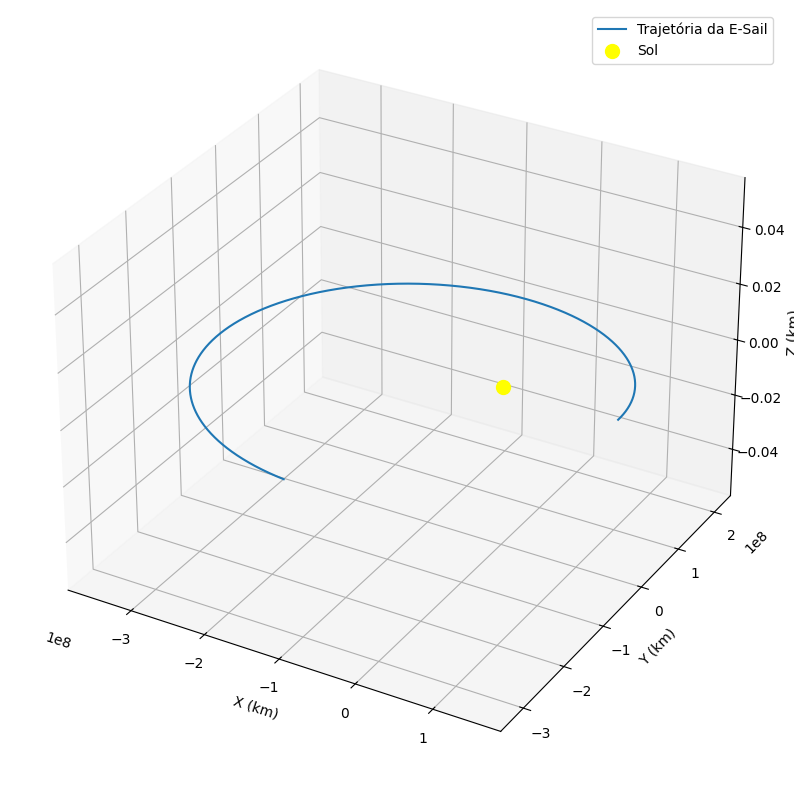

In [17]:
latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)
print(latest_file)

df.columns = create_cols_name(df)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Trajetoria (corpo 1)
ax.plot(df['X1'], df['Y1'], df['Z1'], label='Trajetória da E-Sail')

# Sol (corpo 0)
ax.scatter(df['X0'].iloc[0], df['Y0'].iloc[0], df['Z0'].iloc[0], s=100, color='yellow', label='Sol')

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
plt.show()

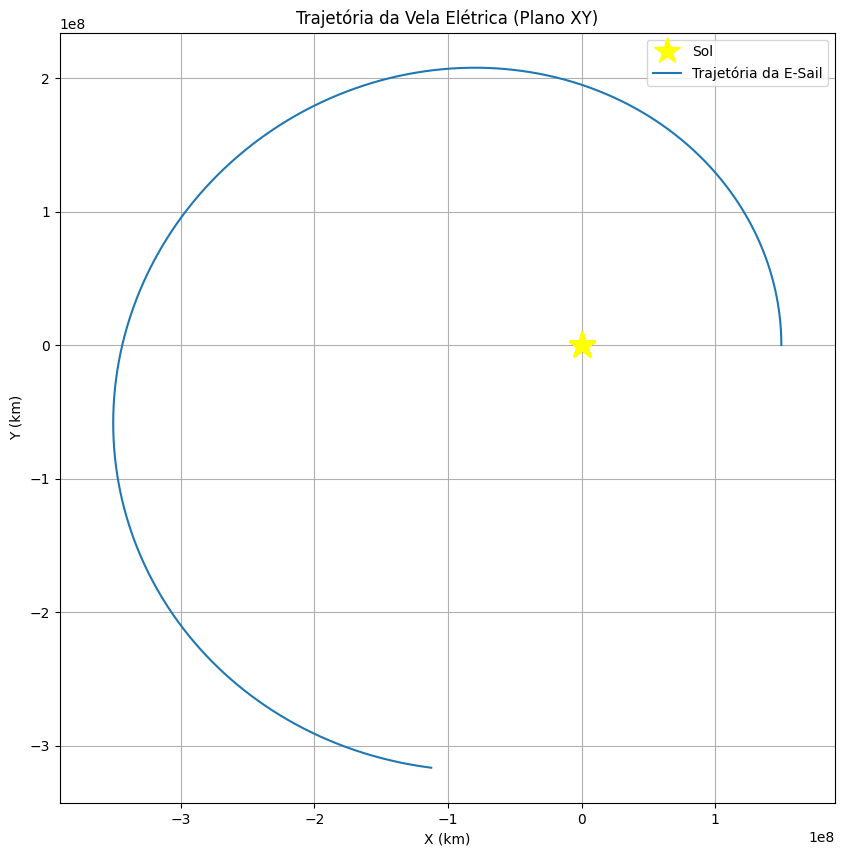

In [18]:

latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)

df.columns = create_cols_name(df)

fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('equal') 

ax.plot(df['X0'], df['Y0'], '*', label='Sol', ms=20, color='yellow')

ax.plot(df['X1'], df['Y1'], label='Trajetória da E-Sail')

ax.set_title("Trajetória da Vela Elétrica (Plano XY)")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.grid(True)
ax.legend()
plt.show()


Primeiro ponto com r >= 1.524 UA em t = 151.56 dias


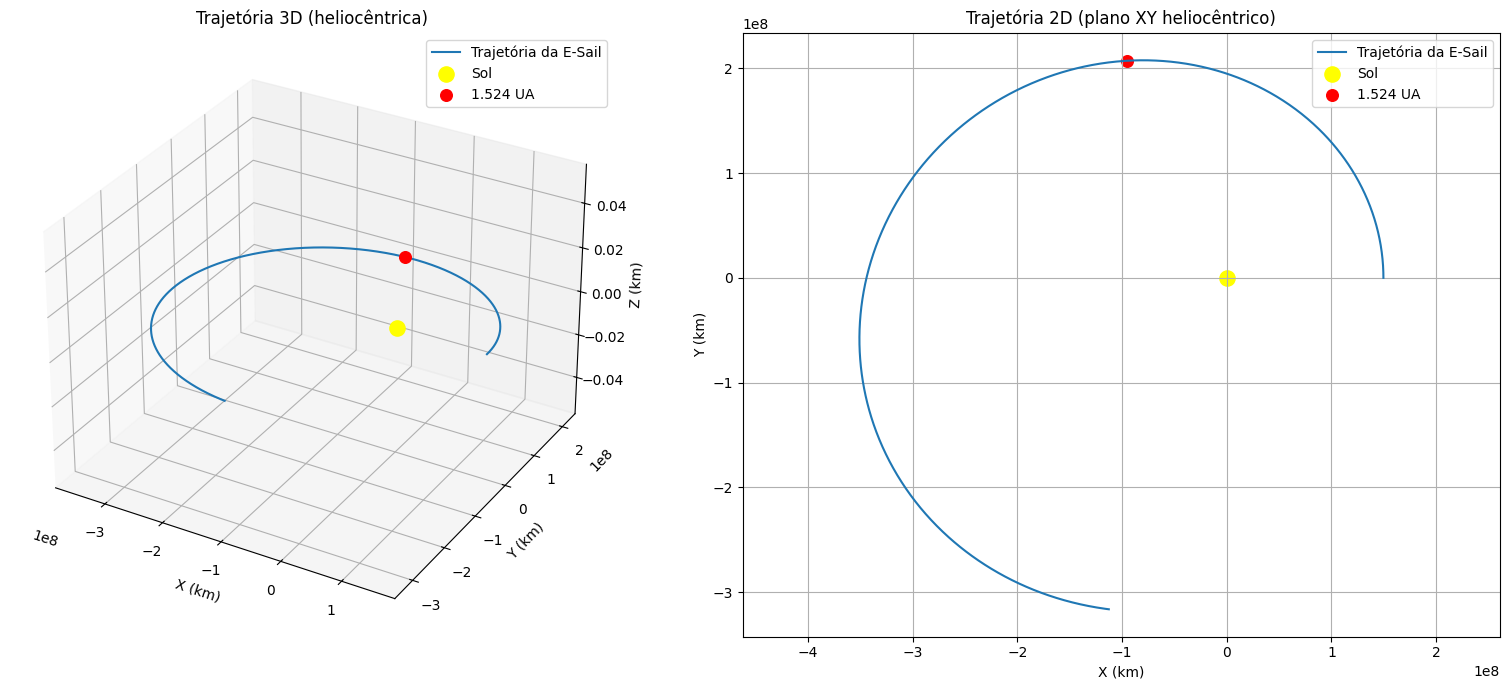

In [19]:
AU_KM = 149597870.7
MARS_ORBIT_AU = 1.524
MARS_ORBIT_KM = MARS_ORBIT_AU * AU_KM

# Trajetória heliocêntrica da vela (em relação ao Sol)
x_rel = df['X1'] - df['X0']
y_rel = df['Y1'] - df['Y0']
z_rel = df['Z1'] - df['Z0']
r_km = np.sqrt(x_rel**2 + y_rel**2 + z_rel**2)

cross_idx = np.where(r_km >= MARS_ORBIT_KM)[0]

if len(cross_idx) == 0:
    print('A vela nao atingiu 1.524 UA.')
else:
    i = cross_idx[0]
    print(f"Primeiro ponto com r >= 1.524 UA em t = {df['T'].iloc[i] / 86400:.2f} dias")

    fig = plt.figure(figsize=(16, 7))

    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot(x_rel, y_rel, z_rel, label='Trajetória da E-Sail')
    ax.scatter(0, 0, 0, s=120, color='yellow', label='Sol')
    ax.scatter(x_rel.iloc[i], y_rel.iloc[i], z_rel.iloc[i], color='red', s=70, label='1.524 UA')
    ax.set_title('Trajetória 3D (heliocêntrica)')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    ax.legend()

    ax = fig.add_subplot(1, 2, 2)
    ax.axis('equal')
    ax.plot(x_rel, y_rel, label='Trajetória da E-Sail')
    ax.scatter(0, 0, s=120, color='yellow', label='Sol')
    ax.scatter(x_rel.iloc[i], y_rel.iloc[i], color='red', s=70, label='1.524 UA')
    ax.set_title('Trajetória 2D (plano XY heliocêntrico)')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [20]:
def cartesian_to_keplerian(r_vec, v_vec, mu):
    """
    Converte vetores cartesianos (posição e velocidade)
    para elementos orbitais keplerianos. Ajustada para quando a orbita é equatorial ou circular
    """
    r_mag = np.linalg.norm(r_vec)
    if r_mag == 0: return (0,0,0,0,0,0)

    v_mag = np.linalg.norm(v_vec)
    h_vec = np.cross(r_vec, v_vec)
    h_mag = np.linalg.norm(h_vec)
    k_hat = np.array([0, 0, 1])
    n_vec = np.cross(k_hat, h_vec)
    n_mag = np.linalg.norm(n_vec)
    e_vec = (1/mu) * ((v_mag**2 - mu/r_mag) * r_vec - np.dot(r_vec, v_vec) * v_vec)
    e = np.linalg.norm(e_vec)
    
    
    # energia e semieixo maior
    energia = (v_mag**2 / 2) - (mu / r_mag)
    if not np.isclose(e, 1.0):
        a = -mu / (2 * energia)
    else:
        a = np.inf

    # inclinação
    i = np.arccos(h_vec[2] / h_mag)

    # i ≈ 0
    if np.isclose(i, 0.0):
        OMEGA = 0 
        omega = np.arccos(e_vec[0] / e)
        if e_vec[1] < 0:
            omega = 2 * np.pi - omega
    # i ≠ 0
    else:
        OMEGA = np.arccos(n_vec[0] / n_mag)
        if n_vec[1] < 0:
            OMEGA = 2 * np.pi - OMEGA
        
        omega = np.arccos(np.dot(n_vec, e_vec) / (n_mag * e))
        if e_vec[2] < 0:
            omega = 2 * np.pi - omega

    # e ≈ 0
    if np.isclose(e, 0.0):
        if np.isclose(i, 0.0):
            nu = np.arccos(r_vec[0] / r_mag)
            if r_vec[1] < 0:
                nu = 2 * np.pi - nu
        else:
            nu = np.arccos(np.dot(n_vec, r_vec) / (n_mag * r_mag))
            if r_vec[2] < 0:
                nu = 2 * np.pi - nu
    # e ≠ 0 e i ≠ 0
    else:
        nu = np.arccos(np.dot(e_vec, r_vec) / (e * r_mag))
        if np.dot(r_vec, v_vec) < 0:
            nu = 2 * np.pi - nu

    i_deg = np.rad2deg(i)
    OMEGA_deg = np.rad2deg(OMEGA)
    omega_deg = np.rad2deg(omega)
    nu_deg = np.rad2deg(nu)

    return (a, e, i_deg, OMEGA_deg, omega_deg, nu_deg)

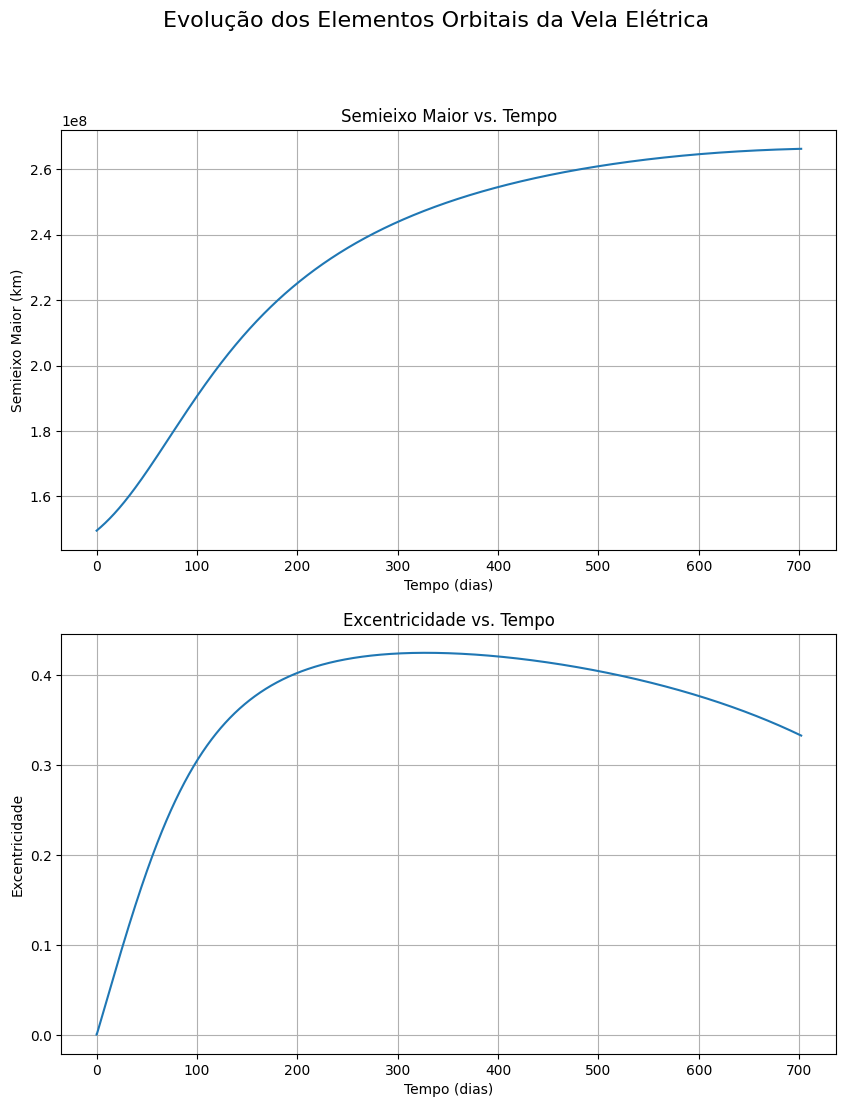

In [21]:
MU_SUN = 1.3271244e11 # em km^3/s^2

latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)

df.columns = create_cols_name(df)

lista_semieixo = []
lista_excentricidade = []

for index, row in df.iterrows():
    r_vec = row[['X1', 'Y1', 'Z1']].values
    v_vec = row[['Vx1', 'Vy1', 'Vz1']].values
    
    a, e, i, Omega, omega, nu = cartesian_to_keplerian(r_vec, v_vec, MU_SUN)
    
    lista_semieixo.append(a)
    lista_excentricidade.append(e)

df['semieixo_maior'] = lista_semieixo
df['excentricidade'] = lista_excentricidade


%matplotlib inline

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
fig.suptitle('Evolução dos Elementos Orbitais da Vela Elétrica', fontsize=16)

tempo_em_dias = df['T'] / 86400

ax1.plot(tempo_em_dias, df['semieixo_maior'])
ax1.set_title('Semieixo Maior vs. Tempo')
ax1.set_xlabel('Tempo (dias)')
ax1.set_ylabel('Semieixo Maior (km)')
ax1.grid(True)

ax2.plot(tempo_em_dias, df['excentricidade'])
ax2.set_title('Excentricidade vs. Tempo')
ax2.set_xlabel('Tempo (dias)')
ax2.set_ylabel('Excentricidade')
ax2.grid(True)

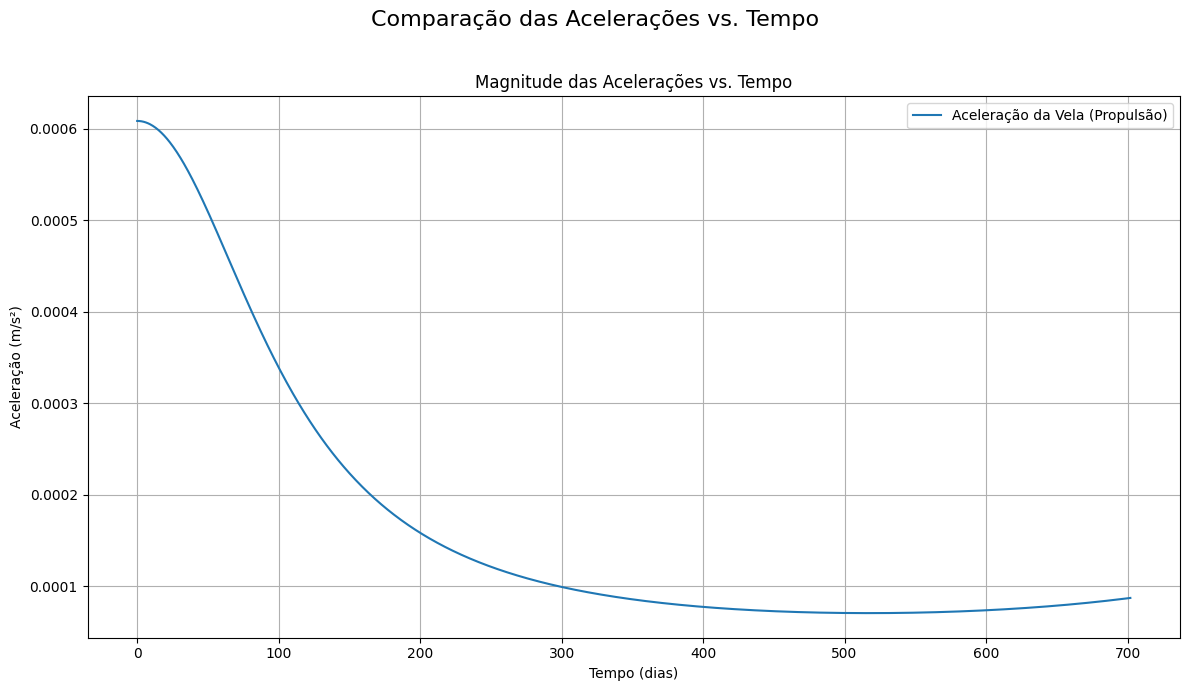

In [22]:
import json 
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from model.electric_probe import ElectricSailProbe


latest_file = files[-1]
df = pd.read_csv(latest_file, header=None)
df.columns = create_cols_name(df)
df_grav = pd.read_csv('gravity_log.csv')


lista_aceleracao_vela_mag = []
lista_aceleracao_vela_vec = []
dados_json = json.load(open('../resources/electric_sail_probe.json'))
params_vela = dados_json['electric_sail_probes'][0]

for index, row in df.iterrows():
    params_atuais = params_vela.copy()

    params_atuais['position'] = row[['X1', 'Y1', 'Z1']].values
    params_atuais['velocity'] = row[['Vx1', 'Vy1', 'Vz1']].values
    
    body_instantaneo = ElectricSailProbe(**params_atuais)
    a_vec_vela = ElectricSailDynamic.calculate_acceleration(body_instantaneo)
    a_vec_vela_ms2 = np.array(a_vec_vela) * 1000  # converte de km/s^2 para m/s^2
    a_mag_vela_ms2 = np.linalg.norm(a_vec_vela_ms2)
    lista_aceleracao_vela_mag.append(a_mag_vela_ms2)
    lista_aceleracao_vela_vec.append(a_vec_vela_ms2)

df['aceleracao_vela_mag'] = lista_aceleracao_vela_mag

# Guarda também as componentes do vetor aceleração (necessário para os plots de aceleração tangencial e do ângulo com a velocidade)
arr_acc_vela = np.array(lista_aceleracao_vela_vec)
df['acc_vela_x'] = arr_acc_vela[:, 0]
df['acc_vela_y'] = arr_acc_vela[:, 1]
df['acc_vela_z'] = arr_acc_vela[:, 2]
#df['aceleracao_grav_mag'] = np.linalg.norm(df_grav[['a_x', 'a_y', 'a_z']].values, axis=1) * 1000 # Converte de km/s^2 para m/s^2

%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Comparação das Acelerações vs. Tempo', fontsize=16)

tempo_em_dias = df['T'] / 86400

ax.plot(tempo_em_dias, df['aceleracao_vela_mag'], label='Aceleração da Vela (Propulsão)')
#ax.plot(tempo_em_dias, df['aceleracao_grav_mag'], label='Aceleração Gravitacional (do Solver)')

ax.set_title('Magnitude das Acelerações vs. Tempo')
ax.set_xlabel('Tempo (dias)')
ax.set_ylabel('Aceleração (m/s²)')
ax.grid(True)
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

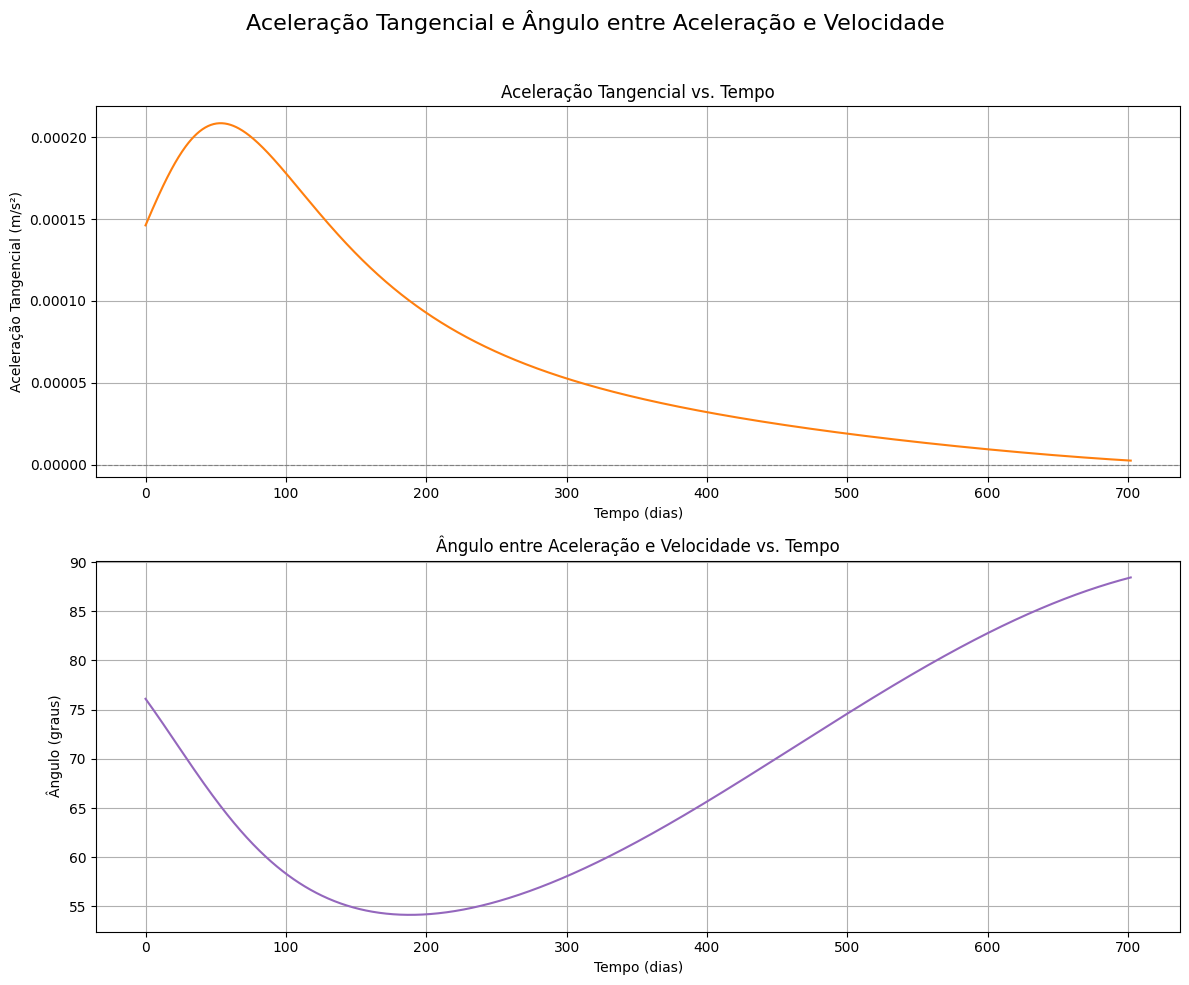

In [23]:
# Vetor velocidade (km/s) da vela
v_vec = df[['Vx1', 'Vy1', 'Vz1']].values
v_mag = np.linalg.norm(v_vec, axis=1)
v_hat = v_vec / v_mag[:, np.newaxis]

# Vetor aceleração (m/s^2) da vela, calculado na célula anterior
a_vec = df[['acc_vela_x', 'acc_vela_y', 'acc_vela_z']].values
a_mag = df['aceleracao_vela_mag'].values

# Aceleração tangencial: projeção escalar de "a" sobre a direção de "v" (a . v_hat)
# Valor positivo = acelerando (empuxo no mesmo sentido do movimento)
# Valor negativo = freando (empuxo contra o movimento)
a_tangencial = np.sum(a_vec * v_hat, axis=1)

# Ângulo entre o vetor aceleração e o vetor velocidade
cos_ang = np.sum(a_vec * v_vec, axis=1) / (a_mag * v_mag)
cos_ang = np.clip(cos_ang, -1.0, 1.0)  # evita erro numérico do arccos
angulo_a_v_deg = np.degrees(np.arccos(cos_ang))

df['aceleracao_tangencial'] = a_tangencial
df['angulo_acc_vel_deg'] = angulo_a_v_deg

%matplotlib inline

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Aceleração Tangencial e Ângulo entre Aceleração e Velocidade', fontsize=16)

tempo_em_dias = df['T'] / 86400

ax1.plot(tempo_em_dias, df['aceleracao_tangencial'], color='tab:orange')
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('Aceleração Tangencial vs. Tempo')
ax1.set_xlabel('Tempo (dias)')
ax1.set_ylabel('Aceleração Tangencial (m/s²)')
ax1.grid(True)

ax2.plot(tempo_em_dias, df['angulo_acc_vel_deg'], color='tab:purple')
ax2.set_title('Ângulo entre Aceleração e Velocidade vs. Tempo')
ax2.set_xlabel('Tempo (dias)')
ax2.set_ylabel('Ângulo (graus)')
ax2.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

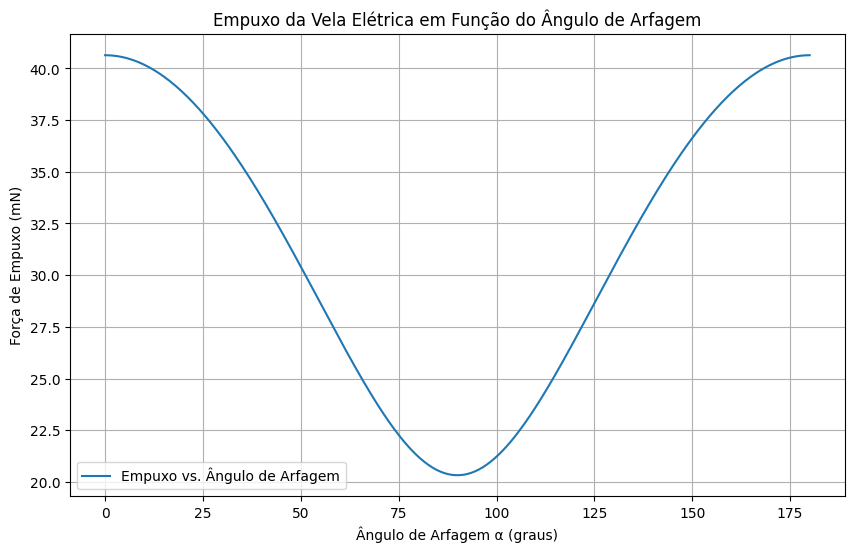

In [24]:
lista_alpha_deg = []
lista_forca_empuxo_N = []

r_base_UA = 1.496e11  # m
row0 = df.iloc[0]

base_params = params_vela.copy()
base_params['position'] = row0[['X1', 'Y1', 'Z1']].values
base_params['velocity'] = row0[['Vx1', 'Vy1', 'Vz1']].values

alpha_degs = np.linspace(0.0, 180.0, 361)

for alpha_deg in alpha_degs:
    params_iter = base_params.copy()
    params_iter['phi_deg'] = alpha_deg
    params_iter['theta_deg'] = 0.0  # ajuste separado se desejar

    body = ElectricSailProbe(**params_iter)

    phi = body.phi
    theta = body.theta

    r_inercial = body.position * 1000.0
    r = np.linalg.norm(r_inercial)

    sigma_F_base = ElectricSailDynamic.calculate_thrust_per_m(body)

    N = body.N
    L = body.L * 1000.0  # m

    prefator = 0.5 * N * L * sigma_F_base * (r_base_UA / r) ** (7.0 / 6.0)

    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    F_vector = prefator * np.array([
        cos_phi * sin_theta * cos_theta,
        -sin_phi * cos_phi * cos_theta**2,
        cos_phi**2 * cos_theta**2 + 1.0
    ])

    alpha = np.arccos(np.clip(cos_phi * cos_theta, -1.0, 1.0))

    lista_alpha_deg.append(np.degrees(alpha))
    lista_forca_empuxo_N.append(np.linalg.norm(F_vector))

df_alpha = pd.DataFrame({
    'alpha_deg': lista_alpha_deg,
    'forca_empuxo_N': lista_forca_empuxo_N
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_alpha['alpha_deg'], df_alpha['forca_empuxo_N']*1000, label='Empuxo vs. Ângulo de Arfagem')
ax.set_xlabel('Ângulo de Arfagem α (graus)')
ax.set_ylabel('Força de Empuxo (mN)')
ax.set_title('Empuxo da Vela Elétrica em Função do Ângulo de Arfagem')
ax.grid(True)
ax.legend()
plt.show()

Total de combinacoes: 4 (4 janelas x 1 valores de phi)
Top 10 combinacoes (menor tempo de chegada):


,launch_start,launch_end,phi_deg,theta_deg,arrival_days
3,2022-01-29,2024-02-08,-30,0,151.570698
1,2018-01-10,2020-01-20,-30,0,218.170698
2,2020-01-20,2022-01-29,-30,0,720.630698
0,2016-01-01,2018-01-10,-30,0,725.810698


Melhor combinacao:
{'launch_start': datetime.datetime(2022, 1, 29, 0, 0), 'launch_end': datetime.datetime(2024, 2, 8, 0, 0), 'phi_deg': -30, 'theta_deg': 0, 'arrival_days': 151.57069837021228}


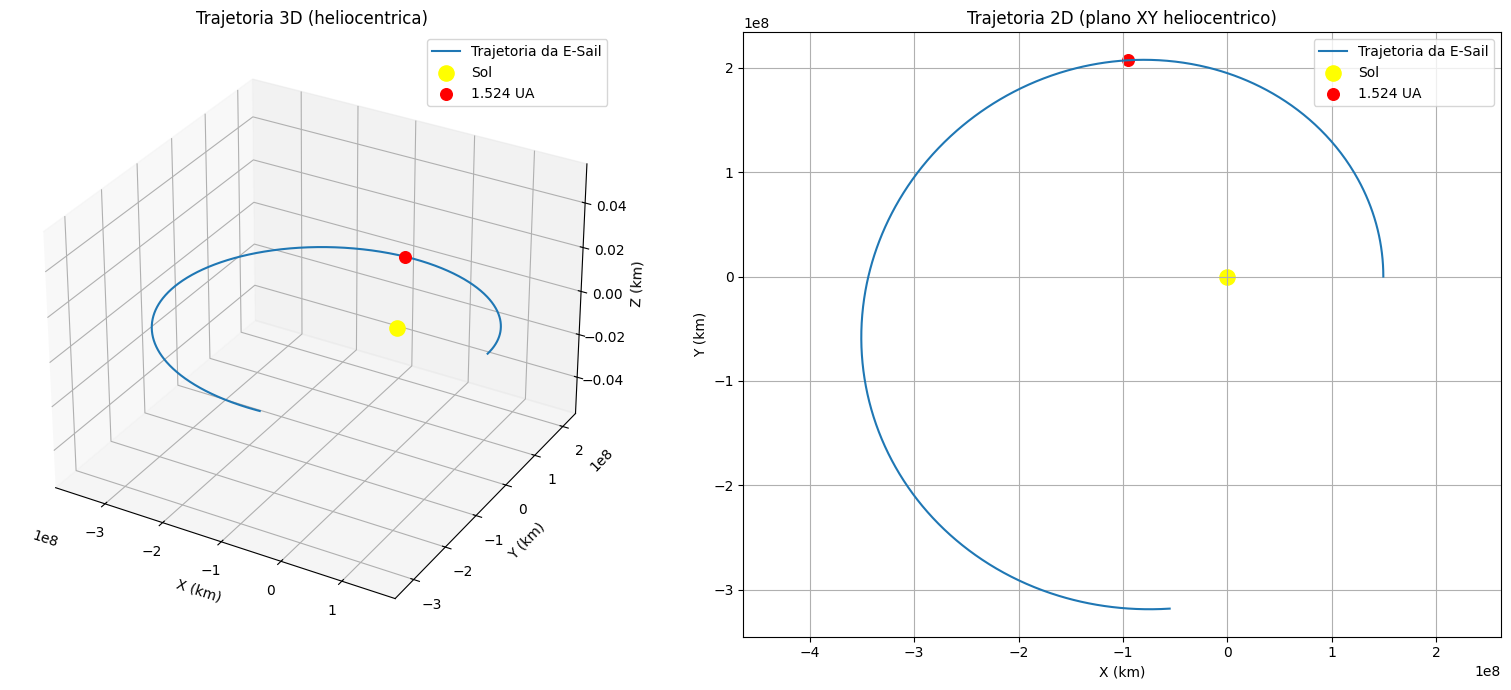

In [25]:
import json
from datetime import datetime, timedelta
from IPython.display import display
from services import n_body_service
from n_body.n_body_solver import NBodySolver, CollisionException
from utils.schemas import RequestDto

# Load solar activity to define valid launch windows
solar_df = pd.read_csv('atividade_solar.csv', sep=r'\s+', header=None, engine='python')
solar_df.columns = ['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s']

def row_to_datetime(row):
    return datetime(int(row['year']), 1, 1) + timedelta(days=int(row['doy']) - 1, hours=int(row['hour']))

dataset_start = row_to_datetime(solar_df.iloc[0])
dataset_end = row_to_datetime(solar_df.iloc[-1])

window_days = 740
step_days = 740
window_delta = timedelta(days=window_days)
step_delta = timedelta(days=step_days)

start_dates = []
current = dataset_start
while current + window_delta <= dataset_end:
    start_dates.append(current)
    current += step_delta

#phi_values = list(range(-50, -19, 5))
phi_values = [-30]
theta_value = 0

total_combinations = len(start_dates) * len(phi_values)
print(f"Total de combinacoes: {total_combinations} ({len(start_dates)} janelas x {len(phi_values)} valores de phi)")

with open('../resources/electric_sail_probe.json', 'r') as f:
    base_config = json.load(f)

AU_KM = 149597870.7
MARS_ORBIT_KM = 1.524 * AU_KM

results = []
best = None
best_df = None
best_cross_idx = None

for start_time in start_dates:
    end_time = start_time + window_delta
    for phi in phi_values:
        config = json.loads(json.dumps(base_config))
        config['start_time'] = start_time.strftime('%Y-%m-%d %H:%M:%S')
        config['end_time'] = end_time.strftime('%Y-%m-%d %H:%M:%S')
        config['electric_sail_probes'][0]['phi_deg'] = float(phi)
        config['electric_sail_probes'][0]['theta_deg'] = float(theta_value)

        data = RequestDto().load(config)
        bodies, time_span = n_body_service.process_data(data)

        solver = NBodySolver(bodies)
        try:
            y_t = solver.solve(time_span=time_span, max_step=time_span / 1000)
        except CollisionException as exc:
            y_t = exc.simulation

        df_run = pd.DataFrame(y_t, columns=create_cols_name(y_t))

        x_rel = df_run['X1'] - df_run['X0']
        y_rel = df_run['Y1'] - df_run['Y0']
        z_rel = df_run['Z1'] - df_run['Z0']
        r_km = np.sqrt(x_rel**2 + y_rel**2 + z_rel**2)
        cross_idx = np.where(r_km >= MARS_ORBIT_KM)[0]

        arrival_days = None
        cross_i = None
        if len(cross_idx) > 0:
            cross_i = int(cross_idx[0])
            arrival_days = float(df_run['T'].iloc[cross_i] / 86400.0)

        results.append({
            'launch_start': start_time,
            'launch_end': end_time,
            'phi_deg': phi,
            'theta_deg': theta_value,
            'arrival_days': arrival_days,
        })

        if arrival_days is not None:
            if best is None or arrival_days < best['arrival_days']:
                best = results[-1]
                best_df = df_run.copy()
                best_cross_idx = cross_i

results_df = pd.DataFrame(results)
results_df_valid = results_df.dropna(subset=['arrival_days']).sort_values('arrival_days')
print('Top 10 combinacoes (menor tempo de chegada):')
display(results_df_valid.head(10))

if best_df is None:
    print('Nenhuma combinacao atingiu a orbita de Marte dentro da janela.')
else:
    print('Melhor combinacao:')
    print(best)

    x_rel = best_df['X1'] - best_df['X0']
    y_rel = best_df['Y1'] - best_df['Y0']
    z_rel = best_df['Z1'] - best_df['Z0']
    i = best_cross_idx

    fig = plt.figure(figsize=(16, 7))
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot(x_rel, y_rel, z_rel, label='Trajetoria da E-Sail')
    ax.scatter(0, 0, 0, s=120, color='yellow', label='Sol')
    ax.scatter(x_rel.iloc[i], y_rel.iloc[i], z_rel.iloc[i], color='red', s=70, label='1.524 UA')
    ax.set_title('Trajetoria 3D (heliocentrica)')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    ax.legend()

    ax = fig.add_subplot(1, 2, 2)
    ax.axis('equal')
    ax.plot(x_rel, y_rel, label='Trajetoria da E-Sail')
    ax.scatter(0, 0, s=120, color='yellow', label='Sol')
    ax.scatter(x_rel.iloc[i], y_rel.iloc[i], color='red', s=70, label='1.524 UA')
    ax.set_title('Trajetoria 2D (plano XY heliocentrico)')
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [26]:
import copy
import json
from datetime import datetime, timedelta
from IPython.display import display

from services import n_body_service
from n_body.n_body_solver import NBodySolver, CollisionException
from utils.schemas import RequestDto
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from model.electric_probe import ElectricSailProbe

solar_df = pd.read_csv('atividade_solar.csv', sep=r'\s+', header=None, engine='python')
solar_df.columns = ['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s']

def row_to_datetime(row):
    return datetime(int(row['year']), 1, 1) + timedelta(
        days=int(row['doy']) - 1,
        hours=int(row['hour'])
    )

def time_average(t, values):
    t = np.asarray(t, dtype=float)
    values = np.asarray(values, dtype=float)
    duration = t[-1] - t[0]
    if duration <= 0:
        return np.nan
    return np.trapezoid(values, t) / duration

def compute_acceleration_mag(df_run, params_vela):
    """Calcula a magnitude da aceleração da vela (m/s^2) em cada instante da trajetória."""
    accs = []
    for _, row in df_run.iterrows():
        params_atuais = params_vela.copy()
        params_atuais['position'] = row[['X1', 'Y1', 'Z1']].values
        params_atuais['velocity'] = row[['Vx1', 'Vy1', 'Vz1']].values

        body_instantaneo = ElectricSailProbe(**params_atuais)
        a_vec_vela = ElectricSailDynamic.calculate_acceleration(body_instantaneo)
        a_mag_vela_ms2 = np.linalg.norm(a_vec_vela) * 1000  # km/s^2 -> m/s^2
        accs.append(a_mag_vela_ms2)

    return np.array(accs)

def mission_wind_stats(df_run, params_vela):
    t = df_run['T'].to_numpy(dtype=float)

    r_rel_m = np.sqrt(
        (df_run['X1'] - df_run['X0'])**2 +
        (df_run['Y1'] - df_run['Y0'])**2 +
        (df_run['Z1'] - df_run['Z0'])**2
    ).to_numpy(dtype=float) * 1000.0

    r_rel_m = np.clip(r_rel_m, 1.0, None)

    r_earth = 1.496e11
    n0 = ElectricSailDynamic._n_earth_m3
    T0 = ElectricSailDynamic._t_e_earth_ev
    v0 = ElectricSailDynamic._v_sw_km_s

    n_t = n0 * (r_earth / r_rel_m) ** 2
    T_t = T0 * (r_earth / r_rel_m) ** (1.0 / 3.0)
    v_t = np.full_like(t, v0, dtype=float)

    # Aceleração da vela ao longo da trajetória (magnitude, m/s^2)
    acc_mag_t = compute_acceleration_mag(df_run, params_vela)

    return {
        'mean_density_m3': time_average(t, n_t),
        'mean_temperature_eV': time_average(t, T_t),
        'mean_speed_km_s': time_average(t, v_t),
        'mean_acceleration_ms2': time_average(t, acc_mag_t),
    }

with open('../resources/electric_sail_probe.json', 'r') as f:
    base_config = json.load(f)

dataset_start = row_to_datetime(solar_df.iloc[0])
dataset_end = row_to_datetime(solar_df.iloc[-1])

window_days = 740
step_days = 740
window_delta = timedelta(days=window_days)
step_delta = timedelta(days=step_days)

start_dates = []
current = dataset_start
while current + window_delta <= dataset_end:
    start_dates.append(current)
    current += step_delta

#phi_values = list(range(-50, -19, 5))
phi_values = [-30]
theta_value = 0

results = []
best = None
best_df = None
best_cross_idx = None

for start_time in start_dates:
    end_time = start_time + window_delta

    for phi in phi_values:
        config = copy.deepcopy(base_config)
        config['start_time'] = start_time.strftime('%Y-%m-%d %H:%M:%S')
        config['end_time'] = end_time.strftime('%Y-%m-%d %H:%M:%S')
        config['electric_sail_probes'][0]['phi_deg'] = float(phi)
        config['electric_sail_probes'][0]['theta_deg'] = float(theta_value)

        data = RequestDto().load(config)
        bodies, time_span = n_body_service.process_data(data)

        solver = NBodySolver(bodies)
        try:
            y_t = solver.solve(time_span=time_span, max_step=time_span / 1000)
        except CollisionException as exc:
            y_t = exc.simulation

        df_run = pd.DataFrame(y_t, columns=create_cols_name(y_t))

        x_rel = df_run['X1'] - df_run['X0']
        y_rel = df_run['Y1'] - df_run['Y0']
        z_rel = df_run['Z1'] - df_run['Z0']
        r_km = np.sqrt(x_rel**2 + y_rel**2 + z_rel**2)

        cross_idx = np.where(r_km >= 1.524 * 149597870.7)[0]

        arrival_days = None
        cross_i = None
        if len(cross_idx) > 0:
            cross_i = int(cross_idx[0])
            arrival_days = float(df_run['T'].iloc[cross_i] / 86400.0)

        # Parâmetros da vela usados nesta corrida (respeitando o phi/theta iterados)
        params_vela_run = config['electric_sail_probes'][0]
        wind_stats = mission_wind_stats(df_run, params_vela_run)

        results.append({
            'launch_start': start_time,
            'launch_end': end_time,
            'phi_deg': phi,
            'theta_deg': theta_value,
            'arrival_days': arrival_days,
            **wind_stats,
        })

        if arrival_days is not None:
            if best is None or arrival_days < best['arrival_days']:
                best = results[-1]
                best_df = df_run.copy()
                best_cross_idx = cross_i

results_df = pd.DataFrame(results)
results_df_valid = results_df.dropna(subset=['arrival_days']).sort_values('arrival_days')

display(
    results_df[
        [
            'launch_start',
            'phi_deg',
            'arrival_days',
            'mean_density_m3',
            'mean_temperature_eV',
            'mean_speed_km_s',
            'mean_acceleration_ms2',
        ]
    ].head(100)
)

print(f'Total de missões simuladas: {len(results_df)}')

global_mean_density = results_df['mean_density_m3'].mean()
global_mean_temperature = results_df['mean_temperature_eV'].mean()
global_mean_speed = results_df['mean_speed_km_s'].mean()
global_mean_acceleration = results_df['mean_acceleration_ms2'].mean()

print('Médias globais a partir das médias por missão:')
print(f'Densidade média global: {global_mean_density:.6e} m^-3')
print(f'Temperatura média global: {global_mean_temperature:.6f} eV')
print(f'Velocidade média global: {global_mean_speed:.3f} km/s')
print(f'Aceleração média global: {global_mean_acceleration:.6e} m/s^2')

,launch_start,phi_deg,arrival_days,mean_density_m3,mean_temperature_eV,mean_speed_km_s,mean_acceleration_ms2
0,2016-01-01,-30,725.810698,1.361402e+06,5.041655,431.0,0.000311
1,2018-01-10,-30,218.170698,2.161718e+06,4.087204,440.0,0.000337
2,2020-01-20,-30,720.630698,3.311542e+06,1.728818,299.0,0.000296
3,2022-01-29,-30,151.570698,1.338186e+06,12.337798,488.0,0.000324


Total de missões simuladas: 4
Médias globais a partir das médias por missão:
Densidade média global: 2.043212e+06 m^-3
Temperatura média global: 5.798869 eV
Velocidade média global: 414.500 km/s
Aceleração média global: 3.168021e-04 m/s^2


,launch_start,phi_deg,arrival_days,mean_accel_tangential_ms2,mean_accel_total_ms2,launch_density_m3,launch_temperature_eV,launch_speed_km_s
3,2022-01-29,-30,151.570698,0.000129,0.000324,4200000.0,15.330605,488.0
1,2018-01-10,-30,218.170698,0.000100,0.000337,4300000.0,4.615279,440.0
2,2020-01-20,-30,720.630698,0.000087,0.000296,5600000.0,1.894007,299.0
0,2016-01-01,-30,725.810698,0.000092,0.000311,2400000.0,5.565083,431.0


Total de missões simuladas: 4
Missões válidas para os gráficos: 4


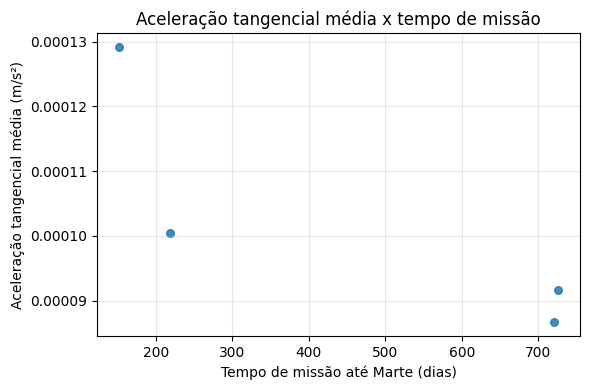

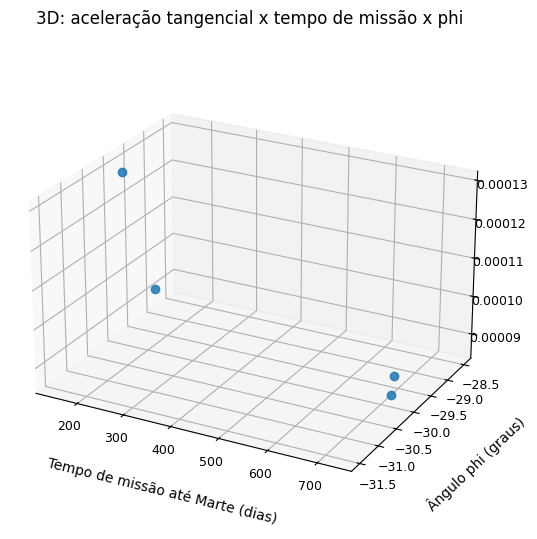

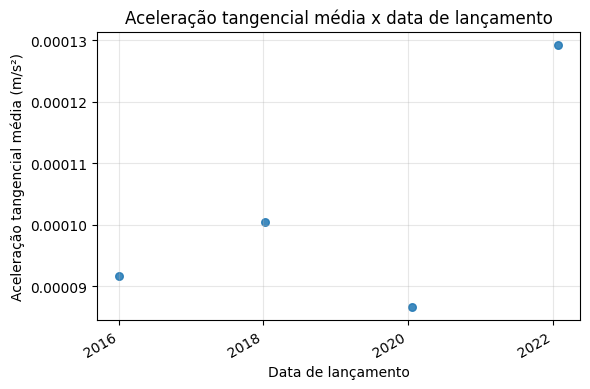

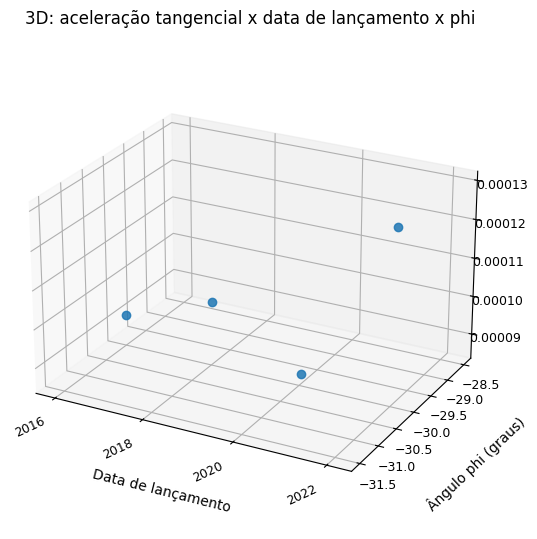

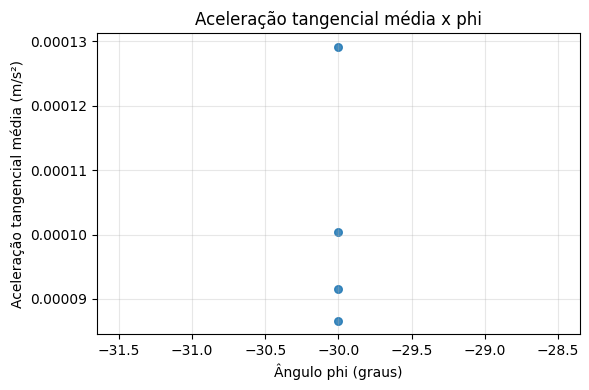

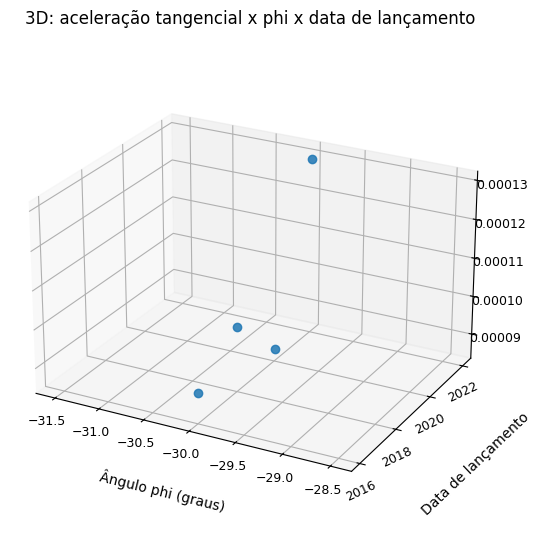

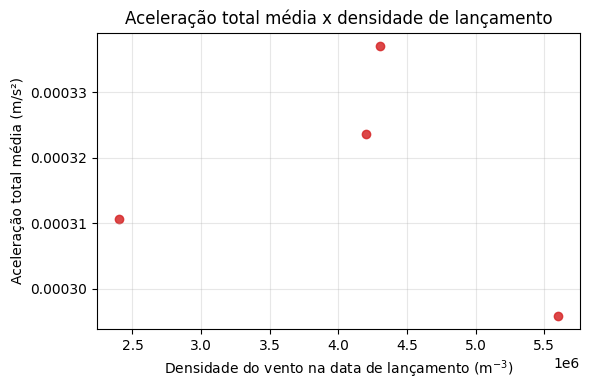

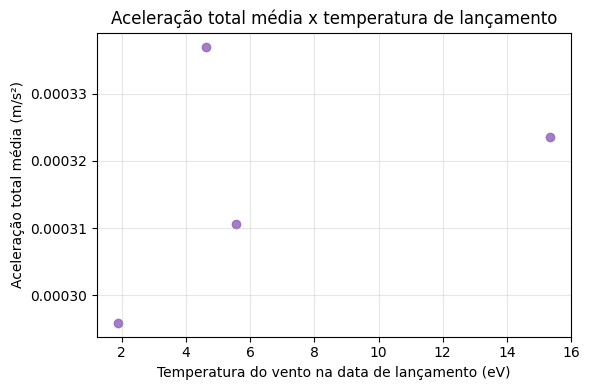

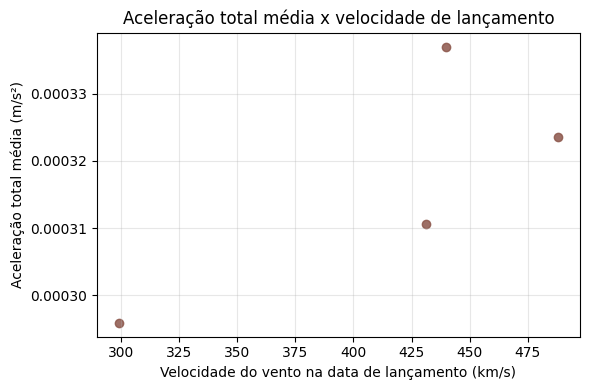

In [29]:
import copy
import json
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

from services import n_body_service
from n_body.n_body_solver import NBodySolver, CollisionException
from utils.schemas import RequestDto
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from model.electric_probe import ElectricSailProbe


solar_df = pd.read_csv('atividade_solar.csv', sep=r'\s+', header=None, engine='python')
solar_df.columns = ['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s']


def row_to_datetime(row):
    return datetime(int(row['year']), 1, 1) + timedelta(
        days=int(row['doy']) - 1,
        hours=int(row['hour'])
    )


def time_average(t, values):
    t = np.asarray(t, dtype=float)
    values = np.asarray(values, dtype=float)
    duration = t[-1] - t[0]
    if duration <= 0:
        return np.nan
    return np.trapezoid(values, t) / duration


def compute_acceleration_profile(df_run, params_vela):
    """Calcula o vetor de aceleração da vela (m/s^2) e sua magnitude em cada instante."""
    accs = []
    for _, row in df_run.iterrows():
        params_atuais = params_vela.copy()
        params_atuais['position'] = row[['X1', 'Y1', 'Z1']].values
        params_atuais['velocity'] = row[['Vx1', 'Vy1', 'Vz1']].values

        body_instantaneo = ElectricSailProbe(**params_atuais)
        a_vec_vela = ElectricSailDynamic.calculate_acceleration(body_instantaneo)
        a_vec_vela_ms2 = np.array(a_vec_vela, dtype=float) * 1000.0  # km/s^2 -> m/s^2
        accs.append(a_vec_vela_ms2)

    a_vec_ms2 = np.array(accs)  # shape (N, 3)
    a_mag_ms2 = np.linalg.norm(a_vec_ms2, axis=1)  # magnitude em cada instante (N,)
    return a_vec_ms2, a_mag_ms2


def compute_tangential_acceleration_profile(df_run, params_vela):
    t = df_run['T'].to_numpy(dtype=float)

    v_vec = df_run[['Vx1', 'Vy1', 'Vz1']].to_numpy(dtype=float)
    v_mag = np.linalg.norm(v_vec, axis=1)
    v_mag = np.clip(v_mag, 1e-30, None)
    v_hat = v_vec / v_mag[:, np.newaxis]

    a_vec_ms2, a_total_ms2 = compute_acceleration_profile(df_run, params_vela)
    a_tangential = np.sum(a_vec_ms2 * v_hat, axis=1)  # produto escalar a . v_hat

    return t, a_tangential, a_total_ms2

def launch_wind_conditions(start_time):
    year = int(start_time.year)
    doy = int(start_time.timetuple().tm_yday)
    hour = int(start_time.hour)

    mask_day = (solar_df['year'].astype(int) == year) & (solar_df['doy'].astype(int) == doy)
    if not np.any(mask_day):
        raise ValueError(f'No solar wind row found for year={year}, doy={doy}')

    candidates = solar_df[mask_day].copy()
    idx = (candidates['hour'].astype(int) - hour).abs().idxmin()
    row = solar_df.loc[idx]

    launch_density_m3 = float(row['dens_cm3']) * 1e6
    launch_temperature_eV = float(row['temp_k']) / 11604.5
    launch_speed_km_s = float(row['vel_km_s'])

    return launch_density_m3, launch_temperature_eV, launch_speed_km_s


def plot_2d_and_3d_scatter(
    x2d, y2d,
    x3d, y3d, z3d,
    x_label_2d, y_label_2d, title_2d,
    x_label_3d, y_label_3d, z_label_3d, title_3d,
    x_is_date_2d=False,
    x_is_date_3d=False,
    y_is_date_3d=False
):
    x2d_plot = pd.to_datetime(x2d) if x_is_date_2d else x2d

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(x2d_plot, y2d, color='tab:blue', alpha=0.85, s=30)
    ax.set_xlabel(x_label_2d)
    ax.set_ylabel(y_label_2d)
    ax.set_title(title_2d)
    ax.grid(True, alpha=0.3)

    if x_is_date_2d:
        locator = mdates.AutoDateLocator(minticks=3, maxticks=5)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
        fig.autofmt_xdate(rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(9, 6))
    fig.subplots_adjust(left=0.06, right=0.90, bottom=0.12, top=0.92)
    ax = fig.add_subplot(111, projection='3d')

    x3d_plot = pd.to_datetime(x3d) if x_is_date_3d else x3d
    y3d_plot = pd.to_datetime(y3d) if y_is_date_3d else y3d

    if x_is_date_3d:
        x3d_plot = mdates.date2num(x3d_plot)
    if y_is_date_3d:
        y3d_plot = mdates.date2num(y3d_plot)

    ax.scatter(x3d_plot, y3d_plot, z3d, color='tab:blue', alpha=0.85, s=36, depthshade=False)

    ax.set_xlabel(x_label_3d, labelpad=14)
    ax.set_ylabel(y_label_3d, labelpad=14)
    ax.set_zlabel(z_label_3d, labelpad=16)
    ax.set_title(title_3d, pad=18)

    ax.view_init(elev=24, azim=-62)

    try:
        ax.set_box_aspect((1.7, 1.35, 1.0))
    except Exception:
        pass

    ax.tick_params(axis='both', which='major', labelsize=9, pad=2)
    ax.tick_params(axis='z', which='major', labelsize=9, pad=2)

    if x_is_date_3d:
        locator_x = mdates.AutoDateLocator(minticks=3, maxticks=5)
        ax.xaxis.set_major_locator(locator_x)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator_x))
        for tick in ax.xaxis.get_majorticklabels():
            tick.set_rotation(25)
            tick.set_ha('right')

    if y_is_date_3d:
        locator_y = mdates.AutoDateLocator(minticks=3, maxticks=5)
        ax.yaxis.set_major_locator(locator_y)
        ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(locator_y))
        for tick in ax.yaxis.get_majorticklabels():
            tick.set_rotation(25)
            tick.set_ha('right')

    ax.grid(True, alpha=0.25)
    plt.show()


with open('../resources/electric_sail_probe.json', 'r') as f:
    base_config = json.load(f)

dataset_start = row_to_datetime(solar_df.iloc[0])
dataset_end = row_to_datetime(solar_df.iloc[-1])

window_days = 740
step_days = 740
window_delta = timedelta(days=window_days)
step_delta = timedelta(days=step_days)

start_dates = []
current = dataset_start
while current + window_delta <= dataset_end:
    start_dates.append(current)
    current += step_delta

#phi_values = list(range(-50, -19, 5))
phi_values = [-30]
theta_value = 0

results = []
best = None
best_df = None
best_cross_idx = None

for start_time in start_dates:
    end_time = start_time + window_delta

    for phi in phi_values:
        config = copy.deepcopy(base_config)
        config['start_time'] = start_time.strftime('%Y-%m-%d %H:%M:%S')
        config['end_time'] = end_time.strftime('%Y-%m-%d %H:%M:%S')
        config['electric_sail_probes'][0]['phi_deg'] = float(phi)
        config['electric_sail_probes'][0]['theta_deg'] = float(theta_value)

        data = RequestDto().load(config)
        bodies, time_span = n_body_service.process_data(data)

        solver = NBodySolver(bodies)
        try:
            y_t = solver.solve(time_span=time_span, max_step=time_span / 1000)
        except CollisionException as exc:
            y_t = exc.simulation

        df_run = pd.DataFrame(y_t, columns=create_cols_name(y_t))

        x_rel = df_run['X1'] - df_run['X0']
        y_rel = df_run['Y1'] - df_run['Y0']
        z_rel = df_run['Z1'] - df_run['Z0']
        r_km = np.sqrt(x_rel**2 + y_rel**2 + z_rel**2)

        cross_idx = np.where(r_km >= 1.524 * 149597870.7)[0]

        arrival_days = None
        cross_i = None
        if len(cross_idx) > 0:
            cross_i = int(cross_idx[0])
            arrival_days = float(df_run['T'].iloc[cross_i] / 86400.0)

        params_vela_run = config['electric_sail_probes'][0]
        t_tan, a_tan, a_total = compute_tangential_acceleration_profile(df_run, params_vela_run)
        mean_a_tan = time_average(t_tan, a_tan)
        mean_a_total = time_average(t_tan, a_total)

        launch_density_m3, launch_temperature_eV, launch_speed_km_s = launch_wind_conditions(start_time)

        results.append({
            'launch_start': start_time,
            'launch_end': end_time,
            'phi_deg': phi,
            'theta_deg': theta_value,
            'arrival_days': arrival_days,
            'mean_accel_tangential_ms2': mean_a_tan,
            'mean_accel_total_ms2': mean_a_total,
            'launch_density_m3': launch_density_m3,
            'launch_temperature_eV': launch_temperature_eV,
            'launch_speed_km_s': launch_speed_km_s,
        })

        if arrival_days is not None:
            if best is None or arrival_days < best['arrival_days']:
                best = results[-1]
                best_df = df_run.copy()
                best_cross_idx = cross_i

results_df = pd.DataFrame(results)
results_df_valid = results_df.dropna(
    subset=[
        'arrival_days',
        'mean_accel_tangential_ms2',
        'mean_accel_total_ms2',
        'launch_density_m3',
        'launch_temperature_eV',
        'launch_speed_km_s'
    ]
).copy()

display(
    results_df[
        [
            'launch_start',
            'phi_deg',
            'arrival_days',
            'mean_accel_tangential_ms2',
            'mean_accel_total_ms2',
            'launch_density_m3',
            'launch_temperature_eV',
            'launch_speed_km_s'
        ]
    ].sort_values('arrival_days')
)

print(f'Total de missões simuladas: {len(results_df)}')
print(f'Missões válidas para os gráficos: {len(results_df_valid)}')

if len(results_df_valid) < 2:
    print('Não há pontos suficientes para gerar os gráficos.')
else:
    plot_2d_and_3d_scatter(
        results_df_valid['arrival_days'],
        results_df_valid['mean_accel_tangential_ms2'],
        results_df_valid['arrival_days'],
        results_df_valid['phi_deg'],
        results_df_valid['mean_accel_tangential_ms2'],
        'Tempo de missão até Marte (dias)',
        'Aceleração tangencial média (m/s²)',
        'Aceleração tangencial média x tempo de missão',
        'Tempo de missão até Marte (dias)',
        'Ângulo phi (graus)',
        'Aceleração tangencial média (m/s²)',
        '3D: aceleração tangencial x tempo de missão x phi'
    )

    plot_2d_and_3d_scatter(
        results_df_valid['launch_start'],
        results_df_valid['mean_accel_tangential_ms2'],
        results_df_valid['launch_start'],
        results_df_valid['phi_deg'],
        results_df_valid['mean_accel_tangential_ms2'],
        'Data de lançamento',
        'Aceleração tangencial média (m/s²)',
        'Aceleração tangencial média x data de lançamento',
        'Data de lançamento',
        'Ângulo phi (graus)',
        'Aceleração tangencial média (m/s²)',
        '3D: aceleração tangencial x data de lançamento x phi',
        x_is_date_2d=True,
        x_is_date_3d=True
    )

    plot_2d_and_3d_scatter(
        results_df_valid['phi_deg'],
        results_df_valid['mean_accel_tangential_ms2'],
        results_df_valid['phi_deg'],
        results_df_valid['launch_start'],
        results_df_valid['mean_accel_tangential_ms2'],
        'Ângulo phi (graus)',
        'Aceleração tangencial média (m/s²)',
        'Aceleração tangencial média x phi',
        'Ângulo phi (graus)',
        'Data de lançamento',
        'Aceleração tangencial média (m/s²)',
        '3D: aceleração tangencial x phi x data de lançamento',
        y_is_date_3d=True
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(
        results_df_valid['launch_density_m3'],
        results_df_valid['mean_accel_total_ms2'],
        color='tab:red',
        alpha=0.85
    )
    ax.set_xlabel('Densidade do vento na data de lançamento (m$^{-3}$)')
    ax.set_ylabel('Aceleração total média (m/s²)')
    ax.set_title('Aceleração total média x densidade de lançamento')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(
        results_df_valid['launch_temperature_eV'],
        results_df_valid['mean_accel_total_ms2'],
        color='tab:purple',
        alpha=0.85
    )
    ax.set_xlabel('Temperatura do vento na data de lançamento (eV)')
    ax.set_ylabel('Aceleração total média (m/s²)')
    ax.set_title('Aceleração total média x temperatura de lançamento')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(
        results_df_valid['launch_speed_km_s'],
        results_df_valid['mean_accel_total_ms2'],
        color='tab:brown',
        alpha=0.85
    )
    ax.set_xlabel('Velocidade do vento na data de lançamento (km/s)')
    ax.set_ylabel('Aceleração total média (m/s²)')
    ax.set_title('Aceleração total média x velocidade de lançamento')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [1]:
# SIMULAÇÃO CORRIGIDA: vento temporal e atraso de propagação
import copy, json
from datetime import datetime, timedelta
from itertools import combinations
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import RK45
from model.electric_probe import ElectricSailProbe
from solar_sail.electric_sail_dynamic import ElectricSailDynamic
from utils.schemas import RequestDto
from services import n_body_service

AU_M = 1.496e11
AU_KM = AU_M / 1000.0
MARS_ORBIT_KM = 1.524 * AU_KM
G_KM = 6.6742e-20

# PARÂMETROS DA VARREDURA (edite somente esta seção)
WINDOW_DAYS = 740       # duração de cada missão
STEP_DAYS = 740         # espaçamento entre lançamentos
PHI_VALUES = [-30.0]    # uma ou mais inclinações phi (graus)
THETA_VALUES = [0.0]    # uma ou mais inclinações theta (graus)

if WINDOW_DAYS <= 0 or STEP_DAYS <= 0:
    raise ValueError('WINDOW_DAYS e STEP_DAYS devem ser positivos.')
if not PHI_VALUES or not THETA_VALUES:
    raise ValueError('Defina pelo menos um valor em cada lista de ângulos.')

class RetardedWind:
    def __init__(self, frame):
        frame = frame.sort_values(['year', 'doy', 'hour']).reset_index(drop=True)
        self.dates = [
            datetime(int(row.year), 1, 1) + timedelta(
                days=int(row.doy) - 1, hours=int(row.hour)
            )
            for row in frame.itertuples()
        ]
        self.epoch = self.dates[0]
        self.t = np.array([(d - self.epoch).total_seconds() for d in self.dates])
        self.n = frame['dens_cm3'].to_numpy(float) * 1e6
        self.te = frame['temp_k'].to_numpy(float) / 11604.5
        self.v = frame['vel_km_s'].to_numpy(float)

    def _interp(self, values, date):
        x = (date - self.epoch).total_seconds()
        if x < self.t[0] or x > self.t[-1]:
            raise ValueError('Data de vento fora do intervalo: {}'.format(date))
        return float(np.interp(x, self.t, values))

    def at_1au(self, date):
        return self._interp(self.n, date), self._interp(self.te, date), self._interp(self.v, date)

    def at_distance(self, date, radius_m):
        if radius_m <= 0:
            raise ValueError('Distância radial inválida.')
        now = (date - self.epoch).total_seconds()
        dr = radius_m - AU_M
        _, _, v = self.at_1au(date)
        tau = now - dr / max(v * 1000.0, 1e-12)
        for _ in range(12):
            tau_date = self.epoch + timedelta(seconds=float(tau))
            _, _, v = self.at_1au(tau_date)
            new_tau = now - dr / max(v * 1000.0, 1e-12)
            if abs(new_tau - tau) < 1e-3:
                tau = new_tau
                break
            tau = new_tau
        tau_date = self.epoch + timedelta(seconds=float(tau))
        n1, te1, v = self.at_1au(tau_date)
        scale = AU_M / radius_m
        return n1 * scale**2, te1 * scale**(1.0 / 3.0), v, tau_date

solar_data_corr = pd.read_csv(
    'atividade_solar.csv', sep=r'\s+', header=None,
    names=['year', 'doy', 'hour', 'temp_k', 'dens_cm3', 'vel_km_s'],
    engine='python',
)
wind_corr = RetardedWind(solar_data_corr)

def accel_with_corr_wind(body, date):
    n, te, v, _ = wind_corr.at_distance(date, np.linalg.norm(body.position) * 1000.0)
    old = (
        ElectricSailDynamic._n_earth_m3,
        ElectricSailDynamic._t_e_earth_ev,
        ElectricSailDynamic._v_sw_km_s,
    )
    ElectricSailDynamic._n_earth_m3 = n
    ElectricSailDynamic._t_e_earth_ev = te
    ElectricSailDynamic._v_sw_km_s = v
    try:
        return np.asarray(ElectricSailDynamic.calculate_acceleration(body), dtype=float)
    finally:
        (
            ElectricSailDynamic._n_earth_m3,
            ElectricSailDynamic._t_e_earth_ev,
            ElectricSailDynamic._v_sw_km_s,
        ) = old

def corr_derivatives(t, y, bodies, start_date):
    nbody = len(bodies)
    state = np.asarray(y, dtype=float).reshape(2 * nbody, 3)
    for i, body in enumerate(bodies):
        body.position = state[i].copy()
        body.velocity = state[i + nbody].copy()

    acc = np.zeros((nbody, 3), dtype=float)
    for i, j in combinations(range(nbody), 2):
        d = bodies[j].position - bodies[i].position
        r = np.linalg.norm(d)
        if r < bodies[i].radius + bodies[j].radius:
            raise ArithmeticError(
                'Collision detected between {} and {}'.format(
                    bodies[i].name, bodies[j].name
                )
            )
        acc[i] += G_KM * bodies[j].mass * d / r**3
        acc[j] -= G_KM * bodies[i].mass * d / r**3

    date = start_date + timedelta(seconds=float(t))
    for i, body in enumerate(bodies):
        if isinstance(body, ElectricSailProbe):
            acc[i] += accel_with_corr_wind(body, date)
    return np.concatenate((state[nbody:].ravel(), acc.ravel()))

def solve_corr(bodies, start_date, time_span):
    positions = [np.asarray(b.position, float) for b in bodies]
    velocities = [np.asarray(b.velocity, float) for b in bodies]
    y0 = np.concatenate([np.concatenate(positions), np.concatenate(velocities)])
    rows = [np.insert(y0.copy(), 0, 0.0)]
    rk = RK45(
        lambda t, y: corr_derivatives(t, y, bodies, start_date),
        t0=0.0, y0=y0, t_bound=time_span, max_step=time_span / 1000.0,
        rtol=1e-6, atol=1e-9,
    )
    try:
        while rk.status == 'running':
            rk.step()
            rows.append(np.insert(rk.y.copy(), 0, rk.t))
    except ArithmeticError:
        pass
    return np.asarray(rows, dtype=float)

def corr_columns(nbody):
    columns = ['T']
    for i in range(nbody):
        columns += ['X{}'.format(i), 'Y{}'.format(i), 'Z{}'.format(i)]
    for i in range(nbody):
        columns += ['Vx{}'.format(i), 'Vy{}'.format(i), 'Vz{}'.format(i)]
    return columns

def corr_average(t, x):
    t, x = np.asarray(t, float), np.asarray(x, float)
    if len(t) < 2 or t[-1] <= t[0]:
        return np.nan
    trap = getattr(np, 'trapezoid', np.trapz)
    return float(trap(x, t) / (t[-1] - t[0]))

with open('../resources/electric_sail_probe.json', 'r') as f:
    corr_base = json.load(f)

window_corr = timedelta(days=WINDOW_DAYS)
step_corr = timedelta(days=STEP_DAYS)
starts_corr = []
date_corr = wind_corr.dates[0]
while date_corr + window_corr <= wind_corr.dates[-1]:
    starts_corr.append(date_corr)
    date_corr += step_corr

corrected_runs = {}
corrected_rows = []

for start_corr in starts_corr:
    end_corr = start_corr + window_corr
    for phi_corr in PHI_VALUES:
        for theta_corr in THETA_VALUES:
            config = copy.deepcopy(corr_base)
            config['start_time'] = start_corr.strftime('%Y-%m-%d %H:%M:%S')
            config['end_time'] = end_corr.strftime('%Y-%m-%d %H:%M:%S')
            config['electric_sail_probes'][0]['phi_deg'] = float(phi_corr)
            config['electric_sail_probes'][0]['theta_deg'] = float(theta_corr)

            bodies_corr, span_corr = n_body_service.process_data(RequestDto().load(config))
            y_corr = solve_corr(bodies_corr, start_corr, span_corr)
            df_corr = pd.DataFrame(y_corr, columns=corr_columns(len(bodies_corr)))

            relative = df_corr[['X1', 'Y1', 'Z1']].to_numpy() - df_corr[
                ['X0', 'Y0', 'Z0']
            ].to_numpy()
            radius_corr = np.linalg.norm(relative, axis=1)
            crossings = np.where(radius_corr >= MARS_ORBIT_KM)[0]
            cross_corr = int(crossings[0]) if len(crossings) else None
            arrival_corr = (
                float(df_corr['T'].iloc[cross_corr] / 86400.0)
                if cross_corr is not None else None
            )
            key_corr = (start_corr, float(phi_corr), float(theta_corr))
            corrected_runs[key_corr] = {
                'config': config, 'df': df_corr,
                'cross_index': cross_corr, 'arrival_days': arrival_corr,
            }
            corrected_rows.append({
                'launch_start': start_corr, 'launch_end': end_corr,
                'phi_deg': float(phi_corr), 'theta_deg': float(theta_corr),
                'arrival_days': arrival_corr,
            })

arrival_columns = [
    'launch_start', 'launch_end', 'phi_deg', 'theta_deg', 'arrival_days'
]
corrected_results_df = pd.DataFrame(
    corrected_rows, columns=arrival_columns
)
if len(corrected_results_df):
    corrected_results_df = corrected_results_df.sort_values(
        'arrival_days', na_position='last'
    ).reset_index(drop=True)
display(corrected_results_df)

valid_arrivals_corr = corrected_results_df.dropna(subset=['arrival_days'])
if len(valid_arrivals_corr):
    best_corr = valid_arrivals_corr.iloc[0]
    best_key_corr = (
        best_corr['launch_start'],
        best_corr['phi_deg'],
        best_corr['theta_deg'],
    )
    best_run_corr = corrected_runs[best_key_corr]
    print(
        'Melhor missão: lançamento={}, phi={:.1f}°, theta={:.1f}°, '
        'chegada={:.3f} dias'.format(
            best_corr['launch_start'].strftime('%Y-%m-%d'),
            best_corr['phi_deg'],
            best_corr['theta_deg'],
            best_corr['arrival_days'],
        )
    )
else:
    best_corr = None
    best_run_corr = None
    print('Nenhuma missão corrigida alcançou 1.524 UA.')


,launch_start,launch_end,phi_deg,theta_deg,arrival_days
0,2016-01-01,2018-01-10,-30.0,0.0,169.952464
1,2018-01-10,2020-01-20,-30.0,0.0,188.423724
2,2022-01-29,2024-02-08,-30.0,0.0,192.942676
3,2020-01-20,2022-01-29,-30.0,0.0,213.776644


Melhor missão: lançamento=2016-01-01, phi=-30.0°, theta=0.0°, chegada=169.952 dias


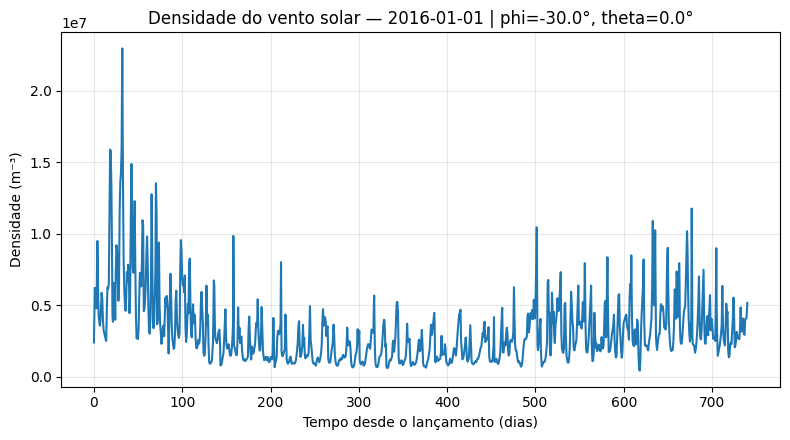

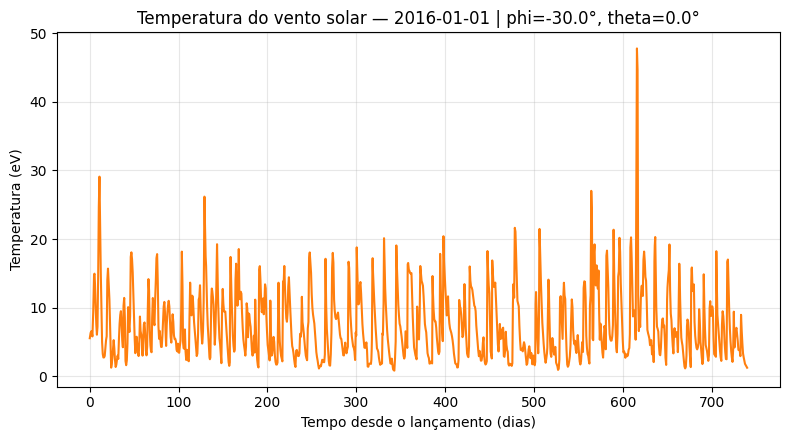

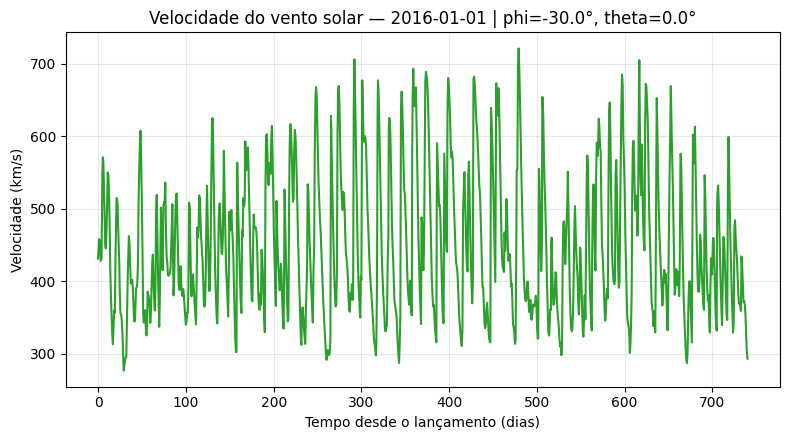

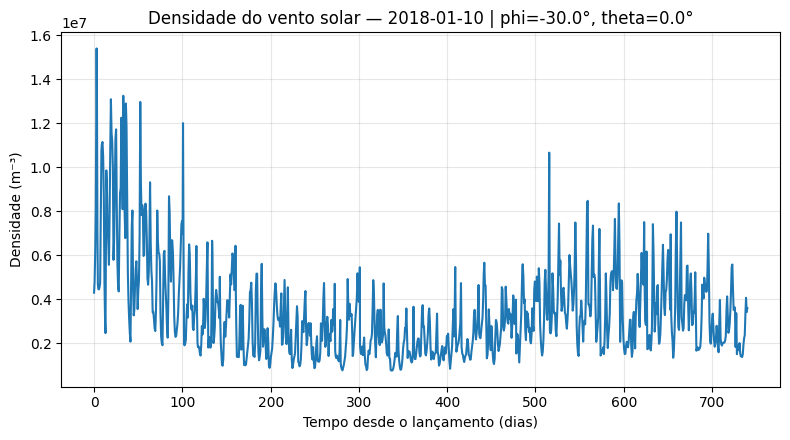

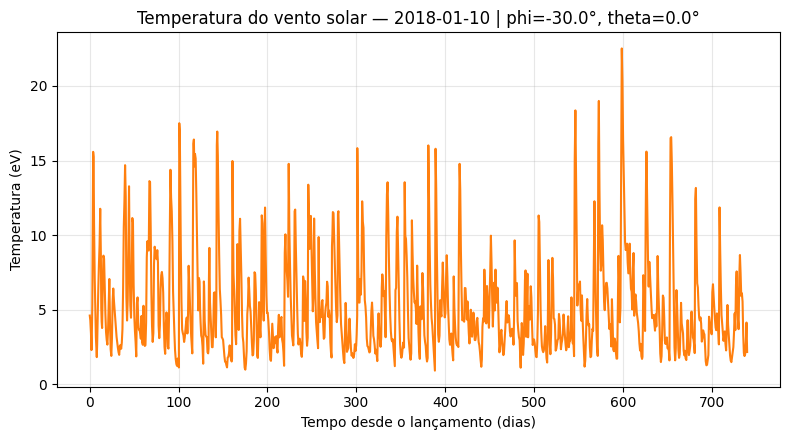

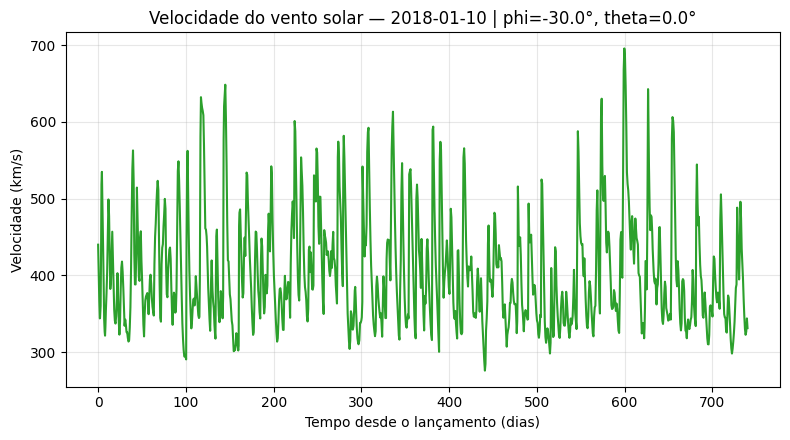

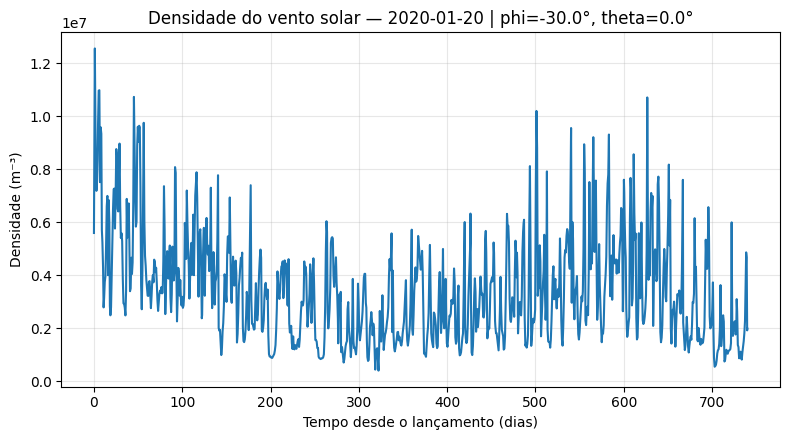

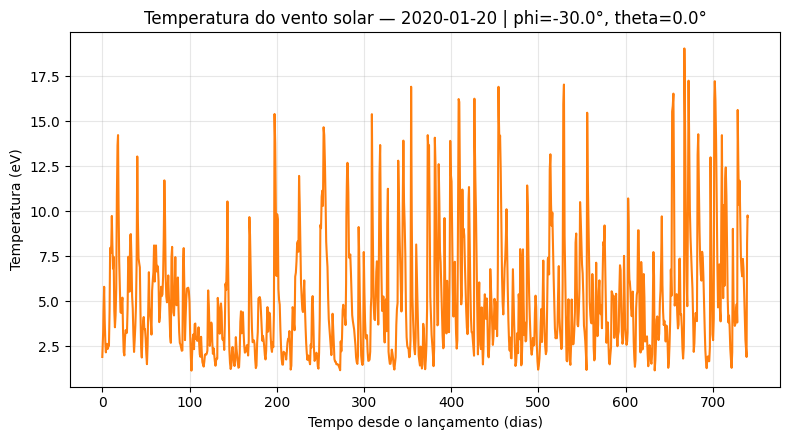

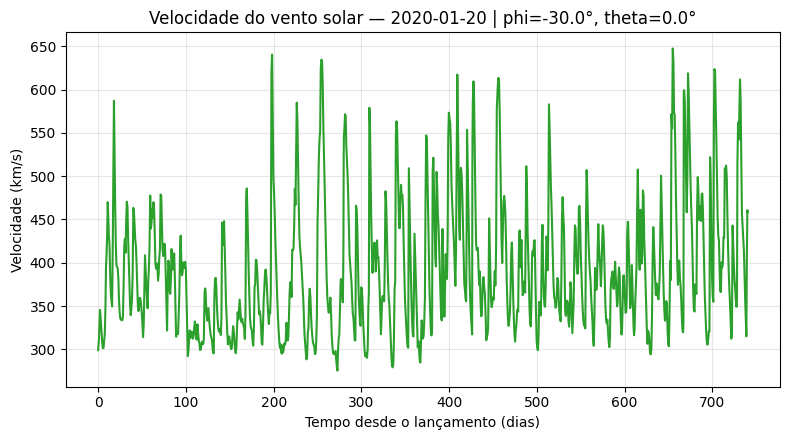

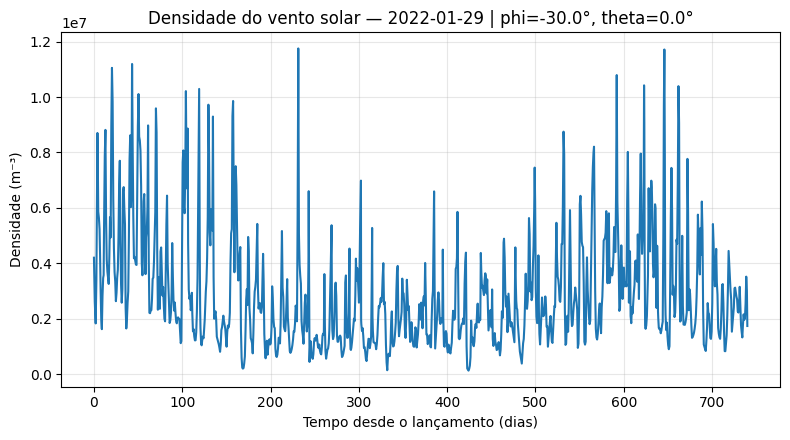

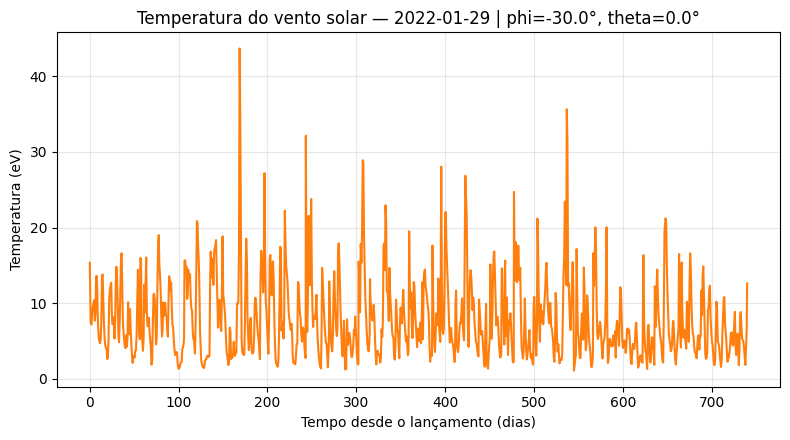

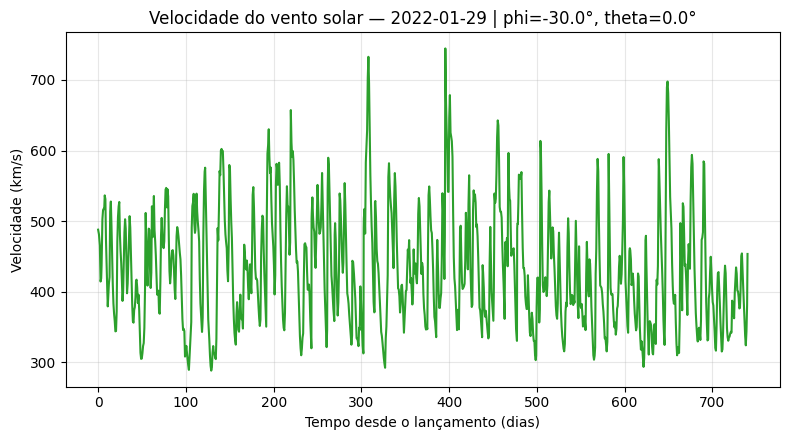

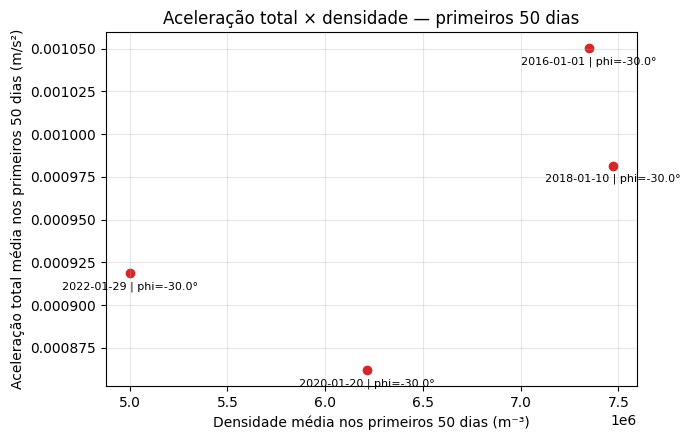

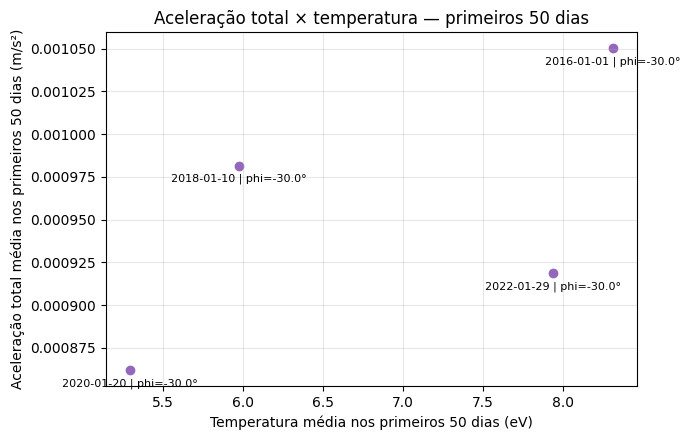

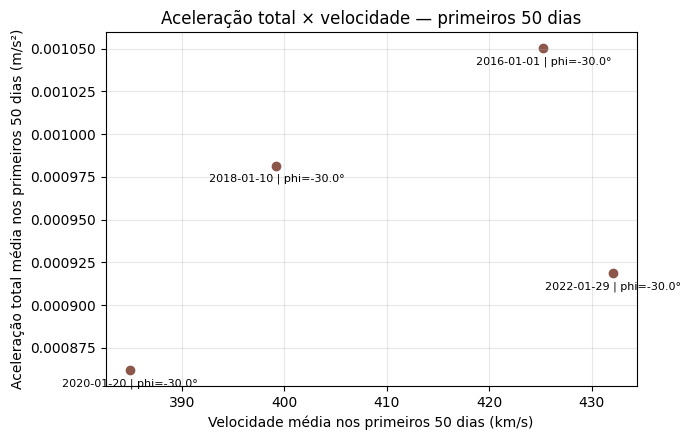

Gráficos temporais gerados: 4 missões × 3 propriedades.
Gráficos agregados gerados: 3; médias calculadas nos primeiros 50 dias.


In [4]:
# propriedades temporais e médias dos primeiros 50 dias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

required_corr = ['corrected_runs', 'wind_corr', 'accel_with_corr_wind',
                 'ElectricSailProbe']
missing_corr = [name for name in required_corr if name not in globals()]
if missing_corr:
    raise RuntimeError(
        'Execute primeiro a célula 15. Variáveis ausentes: {}'.format(
            ', '.join(missing_corr)
        )
    )

PROPERTY_AVERAGING_DAYS = 50
PROPERTY_AVERAGING_SECONDS = PROPERTY_AVERAGING_DAYS * 86400.0

def corr_average_window(t, values, end_seconds=PROPERTY_AVERAGING_SECONDS):
    t = np.asarray(t, dtype=float)
    values = np.asarray(values, dtype=float)
    if len(t) < 2 or end_seconds <= t[0]:
        return np.nan

    end = min(float(end_seconds), float(t[-1]))
    mask = t < end
    t_window = np.concatenate((t[mask], [end]))
    values_window = np.concatenate((
        values[mask],
        [np.interp(end, t, values)],
    ))
    if len(t_window) < 2 or t_window[-1] <= t_window[0]:
        return np.nan

    trap = getattr(np, 'trapezoid', np.trapz)
    return float(
        trap(values_window, t_window) / (t_window[-1] - t_window[0])
    )

def corrected_profiles_for_analysis(df, start_date, parameters):
    acceleration_vectors = []
    wind_values = []

    for _, row in df.iterrows():
        date = start_date + timedelta(seconds=float(row['T']))
        params = parameters.copy()
        params['position'] = row[['X1', 'Y1', 'Z1']].to_numpy(float)
        params['velocity'] = row[['Vx1', 'Vy1', 'Vz1']].to_numpy(float)
        body = ElectricSailProbe(**params)

        acceleration_vectors.append(
            accel_with_corr_wind(body, date) * 1000.0
        )

        relative = row[['X1', 'Y1', 'Z1']].to_numpy(float) - row[
            ['X0', 'Y0', 'Z0']
        ].to_numpy(float)
        wind_values.append(
            wind_corr.at_distance(
                date, np.linalg.norm(relative) * 1000.0
            )[:3]
        )

    acceleration_vectors = np.asarray(acceleration_vectors, dtype=float)
    acceleration_total = np.linalg.norm(acceleration_vectors, axis=1)
    wind_values = np.asarray(wind_values, dtype=float)

    return (
        acceleration_total,
        wind_values[:, 0],
        wind_values[:, 1],
        wind_values[:, 2],
    )

metrics_50d = []

for (start_corr, phi_corr, theta_corr), run_corr in corrected_runs.items():
    df_corr = run_corr['df']
    params_corr = run_corr['config']['electric_sail_probes'][0]
    acceleration_total, density, temperature, speed = (
        corrected_profiles_for_analysis(df_corr, start_corr, params_corr)
    )
    elapsed_days = df_corr['T'].to_numpy(dtype=float) / 86400.0
    label = '{} | phi={:.1f}°, theta={:.1f}°'.format(
        start_corr.strftime('%Y-%m-%d'), phi_corr, theta_corr
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(elapsed_days, density, color='tab:blue')
    ax.set_title('Densidade do vento solar — {}'.format(label))
    ax.set_xlabel('Tempo desde o lançamento (dias)')
    ax.set_ylabel('Densidade (m⁻³)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(elapsed_days, temperature, color='tab:orange')
    ax.set_title('Temperatura do vento solar — {}'.format(label))
    ax.set_xlabel('Tempo desde o lançamento (dias)')
    ax.set_ylabel('Temperatura (eV)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(elapsed_days, speed, color='tab:green')
    ax.set_title('Velocidade do vento solar — {}'.format(label))
    ax.set_xlabel('Tempo desde o lançamento (dias)')
    ax.set_ylabel('Velocidade (km/s)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    metrics_50d.append({
        'launch_start': start_corr,
        'phi_deg': phi_corr,
        'theta_deg': theta_corr,
        'mean_density_50d_m3': corr_average_window(
            df_corr['T'], density
        ),
        'mean_temperature_50d_eV': corr_average_window(
            df_corr['T'], temperature
        ),
        'mean_speed_50d_km_s': corr_average_window(
            df_corr['T'], speed
        ),
        'mean_accel_total_50d_ms2': corr_average_window(
            df_corr['T'], acceleration_total
        ),
    })

metrics_50d_columns = [
    'launch_start', 'phi_deg', 'theta_deg',
    'mean_density_50d_m3', 'mean_temperature_50d_eV',
    'mean_speed_50d_km_s', 'mean_accel_total_50d_ms2',
]
metrics_50d_df = pd.DataFrame(metrics_50d, columns=metrics_50d_columns)

scatter_specs = [
    (
        'mean_density_50d_m3',
        'Densidade média nos primeiros 50 dias (m⁻³)',
        'Aceleração total média nos primeiros 50 dias (m/s²)',
        'Aceleração total × densidade — primeiros 50 dias',
        'tab:red',
    ),
    (
        'mean_temperature_50d_eV',
        'Temperatura média nos primeiros 50 dias (eV)',
        'Aceleração total média nos primeiros 50 dias (m/s²)',
        'Aceleração total × temperatura — primeiros 50 dias',
        'tab:purple',
    ),
    (
        'mean_speed_50d_km_s',
        'Velocidade média nos primeiros 50 dias (km/s)',
        'Aceleração total média nos primeiros 50 dias (m/s²)',
        'Aceleração total × velocidade — primeiros 50 dias',
        'tab:brown',
    ),
]

for x_column, x_label, y_label, title, color in scatter_specs:
    valid = metrics_50d_df.dropna(
        subset=[x_column, 'mean_accel_total_50d_ms2']
    )
    if len(valid) == 0:
        continue
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(
        valid[x_column],
        valid['mean_accel_total_50d_ms2'],
        color=color,
    )
    for _, point in valid.iterrows():
        point_label = '{} | phi={:.1f}°'.format(
            pd.to_datetime(point['launch_start']).strftime('%Y-%m-%d'),
            point['phi_deg'],
        )
        ax.annotate(
            point_label,
            (point[x_column], point['mean_accel_total_50d_ms2']),
            xytext=(0, -6),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=8,
        )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(
    'Gráficos temporais gerados: {} missões × 3 propriedades.'.format(
        len(metrics_50d_df)
    )
)
print(
    'Gráficos agregados gerados: 3; médias calculadas nos primeiros {} dias.'.format(
        PROPERTY_AVERAGING_DAYS
    )
)
